<a href="https://colab.research.google.com/github/Aastha210/MSE2_Lab_DL/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [ ]:
maxlen = 200

X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [ ]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 307ms/step - accuracy: 0.7879 - loss: 0.4436 - val_accuracy: 0.8358 - val_loss: 0.3697
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 304ms/step - accuracy: 0.8998 - loss: 0.2513 - val_accuracy: 0.8716 - val_loss: 0.3028
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 318ms/step - accuracy: 0.9357 - loss: 0.1710 - val_accuracy: 0.8708 - val_loss: 0.3461
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 299ms/step - accuracy: 0.9542 - loss: 0.1285 - val_accuracy: 0.8678 - val_loss: 0.4074


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8602 - loss: 0.4263
Test Accuracy: 0.8601999878883362


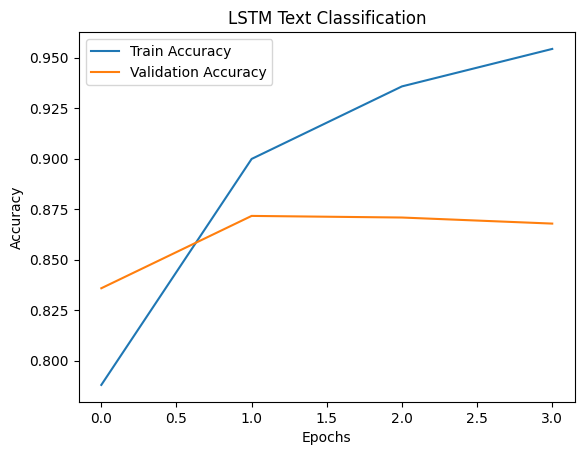

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("LSTM Text Classification")
plt.legend()

plt.show()

In [ ]:
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
input_texts = []
target_texts = []
pairs = [
    ['hi', 'salut'],
    ['hello', 'bonjour'],
    ['how are you', 'comment allez vous'],
    ['i am fine', 'je vais bien'],
    ['thank you', 'merci'],
    ['good night', 'bonne nuit']
]

for pair in pairs:
    input_texts.append(pair[0])
    target_texts.append(pair[1])

In [ ]:
input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(input_texts)

input_sequences = input_tokenizer.texts_to_sequences(input_texts)

max_encoder_len = max(len(seq) for seq in input_sequences)

encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_encoder_len,
    padding='post'
)

In [ ]:
target_tokenizer = Tokenizer()
target_tokenizer.fit_on_texts(target_texts)

target_sequences = target_tokenizer.texts_to_sequences(target_texts)

max_decoder_len = max(len(seq) for seq in target_sequences)

decoder_input_data = pad_sequences(
    target_sequences,
    maxlen=max_decoder_len,
    padding='post'
)

In [ ]:
decoder_target_data = np.expand_dims(decoder_input_data, -1)

In [ ]:
encoder_vocab_size = len(input_tokenizer.word_index) + 1
decoder_vocab_size = len(target_tokenizer.word_index) + 1

print(encoder_vocab_size)
print(decoder_vocab_size)

12
12


In [ ]:
latent_dim = 64

encoder_inputs = Input(shape=(None,))

enc_emb = Embedding(
    encoder_vocab_size,
    latent_dim
)(encoder_inputs)

encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

In [ ]:
decoder_inputs = Input(shape=(None,))

dec_emb_layer = Embedding(
    decoder_vocab_size,
    latent_dim
)

dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

decoder_dense = Dense(
    decoder_vocab_size,
    activation='softmax'
)

decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │        768 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 64)  │        768 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 64),      │     33,024 │ embedding_1[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, None,     │     33,024 │ embedding_2[0][0… │
│                     │ 64), (None, 64),  │            │ lstm_1[0][1],     │
│                     │ (None, 64)]       │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 12)  │        780 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,364 (267.05 KB)

 Trainable params: 68,364 (267.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=2,
    epochs=100
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2222 - loss: 2.4779  
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4444 - loss: 2.4544
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4444 - loss: 2.4314
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4444 - loss: 2.4064
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3889 - loss: 2.3743
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3889 - loss: 2.3368
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3889 - loss: 2.2906
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3889 - loss: 2.2224
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3889 - loss: 2.1450
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4444 - loss: 2.0475
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4444 - loss: 1.9001
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5000 - 

In [ ]:
print("Seq2Seq model trained successfully!")

Seq2Seq model trained successfully!


In [ ]:
predictions = model.predict(
    [encoder_input_data, decoder_input_data]
)

print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
(6, 3, 12)


In [ ]:
reverse_target_index = {
    index: word
    for word, index in target_tokenizer.word_index.items()
}

In [ ]:
predictions = model.predict(
    [encoder_input_data, decoder_input_data]
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [ ]:
for i in range(len(input_texts)):

    print("\nInput:", input_texts[i])

    predicted_sequence = np.argmax(predictions[i], axis=1)

    translated_sentence = []

    for index in predicted_sequence:

        word = reverse_target_index.get(index)

        if word is not None:
            translated_sentence.append(word)

    print("Predicted Translation:", " ".join(translated_sentence))
    print("Actual Translation:", target_texts[i])


Input: hi
Predicted Translation: salut
Actual Translation: salut

Input: hello
Predicted Translation: bonjour
Actual Translation: bonjour

Input: how are you
Predicted Translation: comment allez vous
Actual Translation: comment allez vous

Input: i am fine
Predicted Translation: je vais bien
Actual Translation: je vais bien

Input: thank you
Predicted Translation: merci
Actual Translation: merci

Input: good night
Predicted Translation: bonne nuit
Actual Translation: bonne nuit
